# Multi-Task Face Analysis with PyTorch Lightning

## Introduction

This notebook solves the same eye-localisation task as `multitask_face_plain_pytorch.ipynb`, but uses **PyTorch Lightning** to eliminate boilerplate.

### Plain PyTorch vs PyTorch Lightning

| Responsibility | Plain PyTorch | PyTorch Lightning |
|---------------|--------------|-------------------|
| Training loop | Write manually | `Trainer.fit()` |
| Validation loop | Write manually | `validation_step()` |
| GPU/CPU management | `model.to(device)`, `x.to(device)` | `accelerator="auto"` |
| Checkpointing | Manual `torch.save` | `ModelCheckpoint` callback |
| Early stopping | Manual patience counter | `EarlyStopping` callback |
| Logging | Manual `print` | `self.log()` → CSV/TensorBoard/WandB |
| Gradient clipping | `clip_grad_norm_` | `gradient_clip_val` in Trainer |

**Key insight:** Lightning separates *what* your model does (LightningModule) from *how* it trains (Trainer). This makes experiments reproducible and switching hardware trivial.

## PyTorch Lightning Overview

### `LightningModule`

Encapsulates model + training logic in one class:
- `forward()` — inference
- `training_step(batch, batch_idx)` — one training iteration
- `validation_step(batch, batch_idx)` — one validation iteration
- `test_step(batch, batch_idx)` — one test iteration
- `configure_optimizers()` — returns optimizer + optional scheduler

### `Trainer`

Drives the training loop. Key arguments:
- `accelerator="auto"` — uses GPU if available, CPU otherwise
- `max_epochs` — maximum training epochs
- `callbacks=[...]` — plug-in behaviours (EarlyStopping, ModelCheckpoint)
- `gradient_clip_val` — clips gradient norm each step
- `log_every_n_steps` — logging frequency

### Callbacks

**EarlyStopping:** monitors a metric and stops training when it hasn't improved for `patience` epochs. Prevents wasted compute and overfitting.

**ModelCheckpoint:** saves the best model (by a monitored metric) to disk. After training, `ckpt.best_model_path` points to the best weights.

### `self.log()`

Inside any `*_step` method, `self.log("name", value)` sends the metric to all configured loggers.
- `on_step=True`: log at every batch
- `on_epoch=True`: aggregate (mean) over the epoch and log once

`torchmetrics` objects passed to `self.log()` are *stateful*: they accumulate values across batches and report the correct epoch-level aggregate.

## Model: ResNet-50 + Eye Regression Head

Same architecture as the plain PyTorch notebook: ResNet-50 backbone (ImageNet pre-trained) with the FC head replaced by a dropout + linear eye regression head.

**Sigmoid on output:** $\hat{e} = \sigma(\text{linear}(\mathbf{f})) \in (0,1)^4$ — soft-constrains predictions to the valid coordinate range.

## Notation

| Symbol | Meaning |
|--------|---------|
| $B$ | Batch size (32) |
| $d=2048$ | ResNet-50 feature dimension |
| $\mathbf{e} \in [0,1]^4$ | Ground-truth normalised eye coordinates |
| $\hat{\mathbf{e}}$ | Predicted coordinates |
| $\mathcal{L}_{\text{MSE}}$ | Mean squared error loss |

## Roadmap

1. EDA: load CSV, inspect distributions, visualise samples
2. Dataset class with augmented/eval transforms
3. Lightning model: backbone + head + metrics
4. Configure Trainer with EarlyStopping + ModelCheckpoint
5. Train, test on best checkpoint
6. Plot learning curves from CSV log
7. Visual inference

In [ ]:
!pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 51.9 MB/s eta 0:00:00


## Setup and Configuration

All hyperparameters are stored in a `Config` dataclass for reproducibility:

In [ ]:

# ------------------- Setup & Configuration ------------------- #
import os
from dataclasses import dataclass
from pathlib import Path
import math

import lightning as L
import pandas as pd
import torch
from PIL import Image, ImageDraw
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torch.optim.lr_scheduler import StepLR
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchmetrics import MeanSquaredError, Accuracy
from torchvision import transforms, models
import matplotlib.pyplot as plt

# Make plots a bit nicer inline
%matplotlib inline

# ---- Paths (edit these to your data) ----
DATA_CSV = 'data/data.csv'
IMAGES_DIR = 'data/images'
SAVE_DIR = 'logs/'

@dataclass
class Config:
    save_dir: str = SAVE_DIR
    batch_size: int = 32
    max_epochs: int = 3
    patience: int = 5
    accelerator: str = "auto"
    devices: int = 1
    learning_rate: float = 1e-4
    num_workers: int = 8
    drop_value: float = 0.5
    seed: int = 42
    grad_clip_val: float = 1.0   # 0 to disable


## Data Download

In [ ]:
import gdown
import zipfile
import os

file_id = '1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF'
url = f'https://drive.google.com/uc?id={file_id}'

output = 'downloaded_file.zip'
gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('data')

os.remove(output)
print('Download and extraction completed successfully.')

Downloading...
From (original): https://drive.google.com/uc?id=1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF
From (redirected): https://drive.google.com/uc?id=1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF&confirm=t&uuid=998826b0-de55-4b22-ab2a-9cfcb66a87d2
To: /content/downloaded_file.zip
100%|██████████| 34.8M/34.8M [00:00<00:00, 36.1MB/s]


Download and extraction completed successfully.


## 1) Quick EDA

CSV rows: 5000


,im_name,gender,left_eye_x,left_eye_y,right_eye_x,right_eye_y,age
0,0.jpg,male,70,111,107,111,37
1,1.jpg,male,71,110,106,111,31
2,2.jpg,male,71,111,106,110,37
3,3.jpg,male,68,111,108,112,51
4,4.jpg,male,71,111,106,110,36



Missing expected columns: ['filename']

Basic describe:


,left_eye_x,left_eye_y,right_eye_x,right_eye_y,age
count,5000.00000,5000.00000,5000.00000,5000.000000,5000.000000
mean,69.39320,111.18780,107.60540,111.144200,37.074200
std,1.73931,1.12338,1.70689,1.179866,8.533819
min,60.00000,104.00000,93.00000,100.000000,11.000000
25%,68.00000,111.00000,107.00000,111.000000,32.000000
50%,69.00000,111.00000,108.00000,111.000000,35.000000
75%,70.00000,112.00000,109.00000,112.000000,40.000000
max,86.00000,117.00000,114.00000,122.000000,77.000000



Gender counts:


,count
gender,
female,2884
male,2116


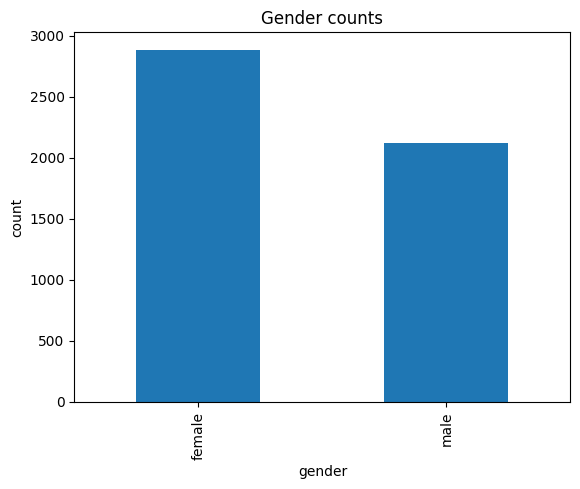

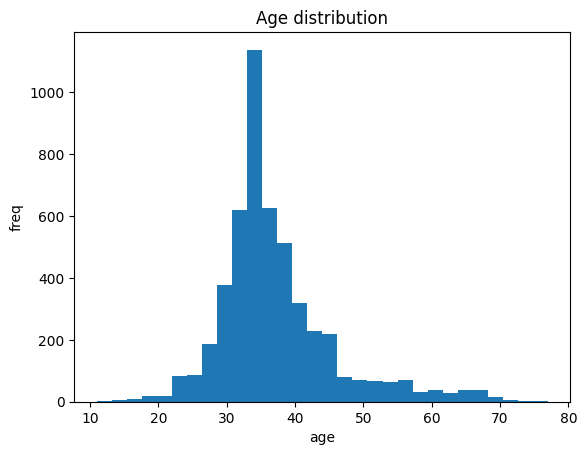

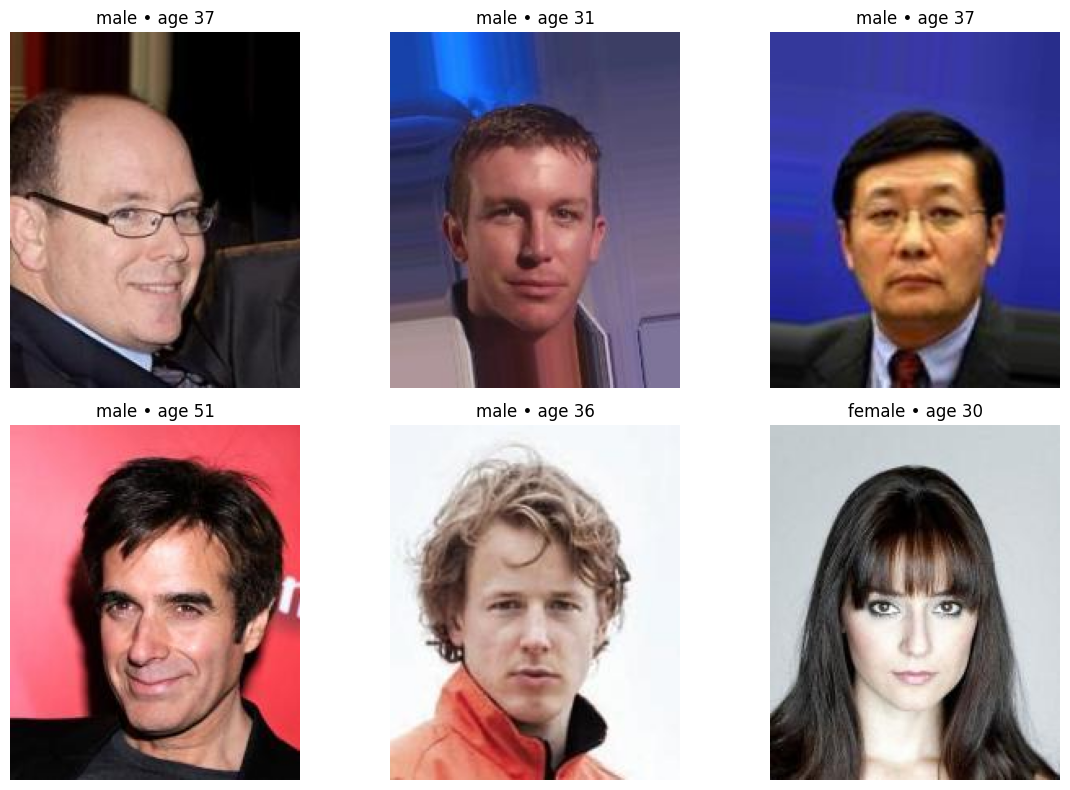

In [ ]:

# ---- Load CSV ----
df = pd.read_csv(DATA_CSV)
print(f"CSV rows: {len(df)}")
display(df.head())

# Expected columns for reference:
expected_cols = ['filename', 'gender', 'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'age']
print("\nMissing expected columns:", [c for c in expected_cols if c not in df.columns])

# ---- Basic stats ----
print("\nBasic describe:")
display(df[['left_eye_x','left_eye_y','right_eye_x','right_eye_y','age']].describe(include='all'))

# ---- Gender balance ----
if 'gender' in df.columns:
    gb = df['gender'].value_counts(dropna=False)
    print("\nGender counts:")
    display(gb.to_frame('count'))

    # Plot with matplotlib (no seaborn)
    plt.figure()
    gb.plot(kind='bar')
    plt.title('Gender counts')
    plt.xlabel('gender')
    plt.ylabel('count')
    plt.show()

# ---- Age histogram ----
if 'age' in df.columns:
    plt.figure()
    df['age'].dropna().astype(float).plot(kind='hist', bins=30)
    plt.title('Age distribution')
    plt.xlabel('age')
    plt.ylabel('freq')
    plt.show()

# ---- Sanity check: a few images ----
def show_samples(n=6):
    n = min(n, len(df))
    cols = 3
    rows = math.ceil(n/cols)
    plt.figure(figsize=(cols*4, rows*4))
    for i in range(n):
        row = df.iloc[i]
        img_path = os.path.join(IMAGES_DIR, row['im_name'])
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Could not open {img_path}: {e}")
            break
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        ttl = f"{row.get('gender','?')} • age {row.get('age','?')}"
        plt.title(ttl)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(6)


## Dataset and Transforms

### Training Augmentations

We apply stronger augmentations during training to improve generalisation:
- `ColorJitter`: random brightness/contrast/saturation/hue perturbation
- `GaussianBlur`: random blur (helps with robustness to image quality)

No augmentation at evaluation time — we want consistent, deterministic predictions.

### Coordinate Normalisation

Eye coordinates are normalised to $[0,1]$ relative to image dimensions. See `multitask_face_plain_pytorch.ipynb` for the mathematical motivation.

## 2) Dataset & Transforms

In [ ]:

class CustomDataset(Dataset):
    """
    CSV columns:
      filename, gender('male'/'female'), left_eye_x, left_eye_y, right_eye_x, right_eye_y, age
    Eye coords in CSV are pixel coords; we normalize to [0,1] by image size.
    """
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        expected = ["im_name","gender","left_eye_x","left_eye_y","right_eye_x","right_eye_y","age"]
        missing = [c for c in expected if c not in self.data.columns]
        if missing:
            raise ValueError(f"CSV is missing columns: {missing}")
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]  # ok to use iloc here
        img_path = self.root_dir / str(row["im_name"])
        image = Image.open(img_path).convert("RGB")

        # normalize coords to [0,1] using original image size
        w, h = image.width, image.height
        left_eye_x  = float(row["left_eye_x"])  / w
        left_eye_y  = float(row["left_eye_y"])  / h
        right_eye_x = float(row["right_eye_x"]) / w
        right_eye_y = float(row["right_eye_y"]) / h

        # (optional) clip in case of slight annotation drift
        eyes = torch.tensor([left_eye_x, left_eye_y, right_eye_x, right_eye_y],
                            dtype=torch.float32).clamp_(0.0, 1.0)

        sample = {
            "image": image if self.transform is None else self.transform(image),
            "eyes": eyes,
            "path": str(img_path),
        }
        return sample


In [ ]:
# Transforms
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.GaussianBlur(kernel_size=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return train_transform, eval_transform

## Lightning Model: `MultiHeadRegCls`

### Architecture
```
Input image (B, 3, 224, 224)
    ↓ ResNet-50 backbone (ImageNet weights)
    ↓ Dropout(p)
    ↓ Linear(2048, 4)
    ↓ Sigmoid
(B, 4)  — predicted normalised eye coordinates
```

### `_shared_step` Pattern

Both `training_step` and `validation_step` call `_shared_step` to avoid code duplication. This is a Lightning best practice.

### `torchmetrics`

`MeanSquaredError` from `torchmetrics` is a stateful metric that correctly averages over variable-sized batches throughout an epoch. Unlike a running sum, it handles the last (potentially smaller) batch correctly.

## 3) Model (LightningModule)

In [ ]:

class MultiHeadRegCls(L.LightningModule):
    def __init__(self, learning_rate: float, drop_value: float):
        super().__init__()
        self.save_hyperparameters()

        # ===== ResNet-50 backbone =====
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Heads
        self.dropout = nn.Dropout(p=drop_value)
        self.eyes_head = nn.Linear(feat_dim, 4)     # coords in [0,1]

        # Losses
        self.loss_eyes = nn.MSELoss(reduction='mean')

        # Metrics
        self.train_eyes_mse = MeanSquaredError()
        self.val_eyes_mse = MeanSquaredError()
        self.test_eyes_rmse = MeanSquaredError(squared=False)

    def forward(self, x):
        feats = self.dropout(self.backbone(x))
        eyes = torch.sigmoid(self.eyes_head(feats))            # [0,1]
        return eyes

    def _shared_step(self, batch):
        eyes_pred = self.forward(batch['image'])
        loss = self.loss_eyes(eyes_pred, batch['eyes'])
        return loss, eyes_pred

    def training_step(self, batch, _):
        loss, eyes_pred = self._shared_step(batch)

        self.train_eyes_mse.update(eyes_pred, batch['eyes'])

        self.log("train/loss", loss, on_step=False, on_epoch=True)
        self.log("train/mse_eyes", self.train_eyes_mse, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        loss, eyes_pred = self._shared_step(batch)

        self.val_eyes_mse.update(eyes_pred, batch['eyes'])
        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val/mse_eyes", self.val_eyes_mse, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, _):
        _, eyes_pred = self._shared_step(batch)

        self.test_eyes_rmse.update(eyes_pred, batch['eyes'])
        self.log("test/rmse_eyes", self.test_eyes_rmse, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        sched = StepLR(opt, step_size=5, gamma=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "interval": "epoch"}}


## Utility: Draw Eye Boxes

Helper to overlay predicted eye positions as red rectangles on the original image:

## 4) Utility: draw eye boxes

In [ ]:

def draw_eye_boxes(image, eye_positions, box_color=(255, 0, 0), box_width=2):
    image_copy = image.copy()
    draw = ImageDraw.Draw(image_copy)
    lx, ly, rx, ry = eye_positions
    lx = int(lx * image.width); rx = int(rx * image.width)
    ly = int(ly * image.height); ry = int(ry * image.height)
    bbox = 5
    draw.rectangle((lx-bbox, ly-bbox, lx+bbox, ly+bbox), outline=box_color, width=box_width)
    draw.rectangle((rx-bbox, ry-bbox, rx+bbox, ry+bbox), outline=box_color, width=box_width)
    return image_copy


## Data Splits and DataLoaders

We use a 70/15/15 train/val/test split. The `Subset` class creates a view into the full dataset using index lists from `random_split`.

`persistent_workers=True` keeps worker processes alive between batches (avoids spawn overhead on each iteration — important for large datasets).

## 5) Data splits & loaders

In [ ]:

cfg = Config()
L.seed_everything(cfg.seed, workers=True)

train_tf, eval_tf = get_transforms()
full_train = CustomDataset(DATA_CSV, IMAGES_DIR, transform=train_tf)
full_eval  = CustomDataset(DATA_CSV, IMAGES_DIR, transform=eval_tf)

total = len(full_train)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size
idx_train, idx_val, idx_test = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_ds = Subset(full_train, idx_train.indices if hasattr(idx_train, 'indices') else idx_train)
val_ds   = Subset(full_eval,  idx_val.indices if hasattr(idx_val, 'indices') else idx_val)
test_ds  = Subset(full_eval,  idx_test.indices if hasattr(idx_test, 'indices') else idx_test)

common_loader_args = dict(
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    pin_memory=True,
    persistent_workers=cfg.num_workers > 0,
    prefetch_factor=2 if cfg.num_workers > 0 else None,
)
train_dl = DataLoader(train_ds, shuffle=True, **common_loader_args)
val_dl   = DataLoader(val_ds,   shuffle=False, **common_loader_args)
test_dl  = DataLoader(test_ds,  shuffle=False, **common_loader_args)

len(train_ds), len(val_ds), len(test_ds)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


(3500, 750, 750)

## Training

`trainer.fit()` runs the full training loop:
1. Each epoch: `training_step` over all train batches → `validation_step` over all val batches
2. Callbacks run automatically: checkpoint best model, stop early if val_loss plateaus

After training, `ckpt.best_model_path` points to the `.ckpt` file with the best validation loss.

## 6) Train

In [ ]:

model = MultiHeadRegCls(cfg.learning_rate, cfg.drop_value)

logger = CSVLogger(save_dir=cfg.save_dir, name="runs")
ckpt = ModelCheckpoint(
    monitor="val/loss",
    mode="min",
    save_top_k=1,
    save_last=True,
    filename="epoch{epoch:02d}-valloss{val/loss:.3f}",
    auto_insert_metric_name=False,
)
early = EarlyStopping(monitor="val/loss", patience=cfg.patience, mode="min")

trainer = L.Trainer(
    accelerator=cfg.accelerator,
    devices=cfg.devices,
    max_epochs=cfg.max_epochs,
    logger=logger,
    callbacks=[ckpt, early],
    gradient_clip_val=cfg.grad_clip_val if cfg.grad_clip_val > 0 else 0.0,
    log_every_n_steps=50,
)

trainer.fit(model, train_dl, val_dl)
best_ckpt_path = ckpt.best_model_path
print("Best checkpoint:", best_ckpt_path)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | backbone       | ResNet           | 23.5 M | train
1 | dropout        | Dropout          | 0      | train
2 | eyes_head      | Linear           | 8.2 K  | train
3 | loss_eyes      | MSELoss          | 0      | train
4 | train_eyes_mse | MeanSquaredError | 0      | train
5 | val_eyes_mse   | MeanSquaredError | 0      | train
6 | test_eyes_rmse | MeanSquaredError

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 14. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Best checkpoint: logs/runs/version_2/checkpoints/epoch02-valloss0.000.ckpt


## Test Evaluation

`trainer.test(ckpt_path=best_ckpt_path)` evaluates the best checkpoint (not the final weights) on the test set. This gives an unbiased estimate of generalisation performance.

## 7) Test

In [ ]:

# Evaluate with best checkpoint
test_metrics = trainer.test(model=None, dataloaders=test_dl, ckpt_path=best_ckpt_path)
test_metrics


INFO: Restoring states from the checkpoint path at logs/runs/version_2/checkpoints/epoch02-valloss0.000.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at logs/runs/version_2/checkpoints/epoch02-valloss0.000.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at logs/runs/version_2/checkpoints/epoch02-valloss0.000.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at logs/runs/version_2/checkpoints/epoch02-valloss0.000.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test/rmse_eyes       │   0.0066584995947778225   │
└───────────────────────────┴───────────────────────────┘

[{'test/rmse_eyes': 0.0066584995947778225}]

## Learning Curves

Lightning's `CSVLogger` writes metrics to `metrics.csv`. Each row corresponds to a logging event; train and validation metrics are logged at different steps, so the file contains NaN values that we handle by taking the last non-null value per epoch.

## 8) Training/Validation curves

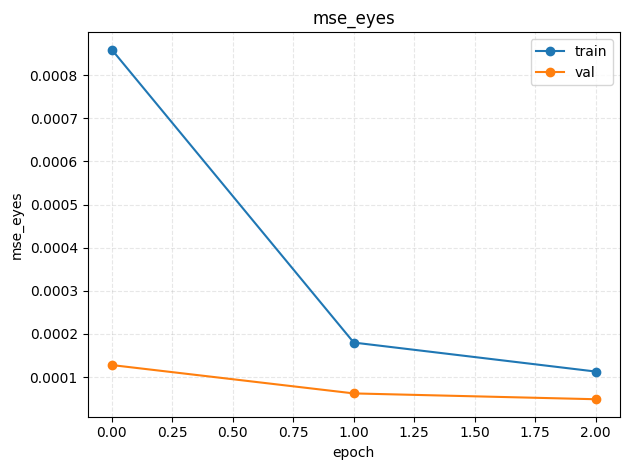

In [ ]:
# --- load ---
metrics_path = Path(logger.log_dir) / "metrics.csv"
df = pd.read_csv(metrics_path)

# ensure epoch is int
df['epoch'] = pd.to_numeric(df['epoch'], errors='coerce')
df = df.dropna(subset=['epoch']).copy()
df['epoch'] = df['epoch'].astype(int)

# aggregate per epoch: take the last non-null for each column (handles duplicated epoch rows)
def last_non_null(s: pd.Series):
    s = pd.to_numeric(s, errors='coerce')  # coerce each series to numeric where possible
    s = s.dropna()
    return s.iloc[-1] if not s.empty else float('nan')

agg = (df.sort_values(['epoch', 'step'] if 'step' in df.columns else ['epoch'])
         .groupby('epoch', as_index=False)
         .agg({col: last_non_null for col in df.columns if col != 'epoch'}))

# metrics to plot (train & val on the same figure)
base_metrics = ['mse_eyes']

for base in base_metrics:
    train_col = f'train/{base}'
    val_col   = f'val/{base}'

    has_train = train_col in agg.columns and agg[train_col].notna().any()
    has_val   = val_col in agg.columns and agg[val_col].notna().any()
    if not (has_train or has_val):
        print(f"Skipping {base}: no train/val data found.")
        continue

    plt.figure()
    if has_train:
        plt.plot(agg['epoch'], agg[train_col], marker='o', label='train')
    if has_val:
        plt.plot(agg['epoch'], agg[val_col], marker='o', label='val')
    plt.title(base)
    plt.xlabel('epoch')
    plt.ylabel(base)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Visual Predictions

Load the best checkpoint, run inference on a test batch, and overlay predicted eye boxes on the original images.

## 9) Visual predictions (inline)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


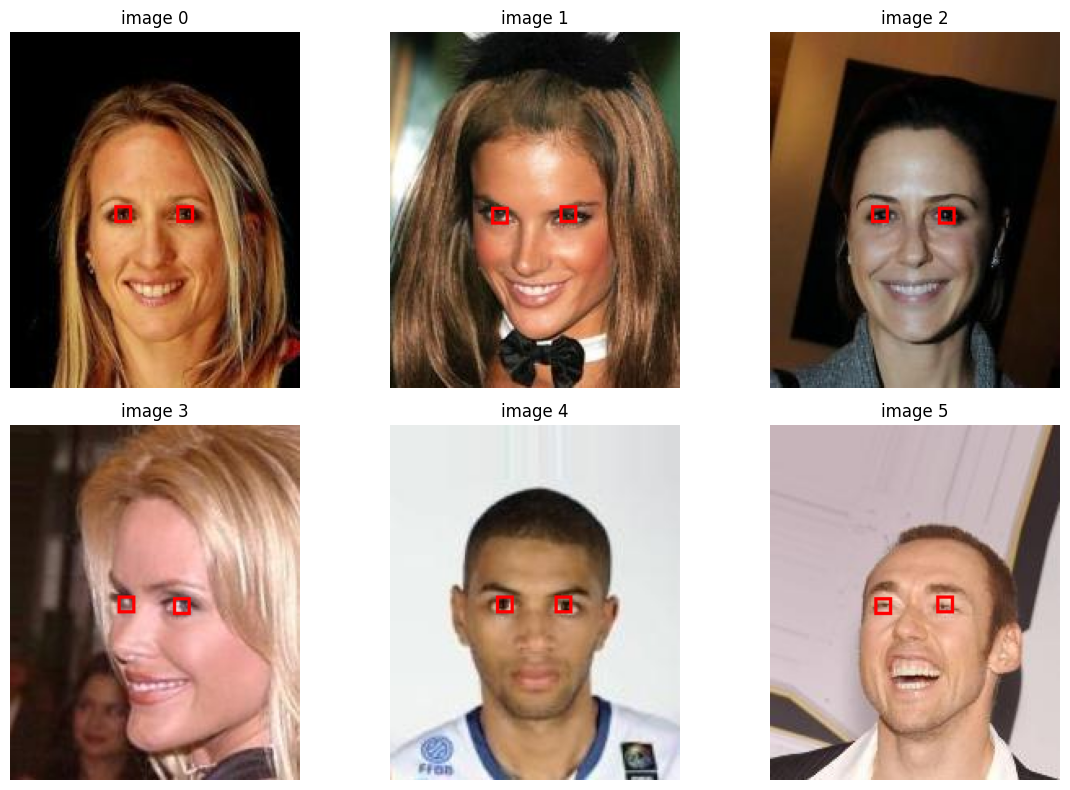

In [ ]:

# Load best checkpoint for inference
model = MultiHeadRegCls.load_from_checkpoint(best_ckpt_path)
model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')

# Grab a small batch
batch = next(iter(test_dl))
device = model.device
with torch.no_grad():
    eyes = model(batch['image'].to(device))

n = min(6, len(batch['path']))
cols = 3
rows = math.ceil(n/cols)
plt.figure(figsize=(cols*4, rows*4))
for i in range(n):
    p = batch['path'][i]
    e = eyes[i].cpu().tolist()
    img = Image.open(p).convert("RGB")
    img_boxes = draw_eye_boxes(img, e)
    plt.subplot(rows, cols, i+1)
    plt.imshow(img_boxes)
    plt.title(f"image {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 10) Notes & Tips
- You can tune loss weights `lambda_age`, `lambda_gender`, `lambda_eyes` in the module.
- If gender classes are imbalanced, adjust `pos_weight` buffer.
- For faster experiments, reduce `max_epochs` and `batch_size`.
- Consider mixed precision (`precision='16-mixed'` in `Trainer`) if you have a modern GPU.
- To resume training from a checkpoint, set `ckpt_path` in `trainer.fit`.

## Reflection Questions

1. **`on_step` vs `on_epoch` logging.** In `self.log("train/loss", loss, on_step=False, on_epoch=True)`, what is the difference between logging on every step vs aggregating per epoch? When would you want `on_step=True`?

2. **`training_step` vs `validation_step` vs `test_step`.** Why does Lightning separate these three methods? What would go wrong if you used `model.train()` mode during validation?

3. **Sigmoid on output.** The model applies `torch.sigmoid` to the eye coordinate predictions. The plain PyTorch version does not. What are the tradeoffs? (Hint: think about gradient flow and constraint satisfaction.)

4. **Extending to age and gender.** How would you add an age regression head and a gender binary classification head to `MultiHeadRegCls`? List all the changes needed (init, forward, losses, metrics, logging).

## Answers

**1. `on_step` vs `on_epoch`.**
`on_step=True` logs after every mini-batch — useful for debugging loss spikes or learning rate schedules within an epoch. `on_epoch=True` averages over all batches and logs once per epoch — cleaner training curves and standard for comparing runs. Use `on_step=True` during debugging; `on_epoch=True` for final training.

**2. Separate step methods.**
Lightning calls `model.train()` before `training_step` and `model.eval()` before `validation_step`/`test_step`. With `model.eval()`: Dropout is disabled (deterministic predictions), BatchNorm uses running statistics (stable estimates). Training with eval-mode Dropout would prevent the regularisation effect; validation with train-mode Dropout would give noisy, non-reproducible metrics.

**3. Sigmoid tradeoff.**
Sigmoid constrains predictions to $(0,1)$, matching the target range. This prevents wild predictions early in training (useful with pre-trained backbone). However, sigmoid saturates for large logits → small gradients when predictions are near 0 or 1. The plain PyTorch version relies entirely on the loss to keep predictions in range, which works fine with MSE.

**4. Adding age + gender.**
In `__init__`: add `self.age_head = nn.Linear(feat_dim, 1)`, `self.gender_head = nn.Linear(feat_dim, 1)`, `self.loss_age = nn.MSELoss()`, `self.loss_gender = nn.BCEWithLogitsLoss()`, plus torchmetrics for each. In `forward`: compute `age = self.age_head(feats)`, `gender = self.gender_head(feats)`. In `_shared_step`: compute total loss `= lambda_eyes * loss_eyes + lambda_age * loss_age + lambda_gender * loss_gender`. In `training_step`/`validation_step`: add `self.log` calls for all metrics.